In [67]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
import os


In [68]:
import os
import shutil
import random

original_train = "/kaggle/input/datasets/vananphan/group-10-emotion-detection/train"
original_test  = "/kaggle/input/datasets/vananphan/group-10-emotion-detection/test"

new_dataset = "/kaggle/working/new_dataset"
os.makedirs(new_dataset, exist_ok=True)

train_dir = os.path.join(new_dataset,"train")
test_dir = os.path.join(new_dataset,"test")
val_dir = os.path.join(new_dataset,"val")


os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


shutil.copytree(
    original_train,
    train_dir,
    dirs_exist_ok=True
)
shutil.copytree(
    original_test,
    test_dir,
    dirs_exist_ok=True
)

print(os.listdir("/kaggle/working/new_dataset"))

['train', 'test', 'val']


In [69]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_disgust = os.path.join(train_dir,"disgust")

os.makedirs(base_disgust, exist_ok = True)

aug_dir = os.path.join("/kaggle/working/aug_disgust")

os.makedirs(aug_dir, exist_ok=True)

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

augment_per_image = 2

for img_name in os.listdir(base_disgust):

    img_path = os.path.join(base_disgust, img_name)

    img = load_img(
        img_path,
        color_mode="grayscale",
        target_size=(48,48)
    )

    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    i = 0

    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=aug_dir,
        save_prefix="disgust",
        save_format="jpg"
    ):

        i += 1

        if i >= augment_per_image:
            break

for img in os.listdir(aug_dir):
    
    shutil.copy(os.path.join(aug_dir,img),
        base_disgust
    )

In [70]:
train_gen = ImageDataGenerator(rescale=1./255,validation_split=0.3)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=16,
    class_mode="categorical",
    subset="training"
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=16,
    class_mode="categorical",
    subset="validation"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=16,
    class_mode="categorical"
)

Found 27098 images belonging to 7 classes.
Found 11610 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [71]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = keras.Sequential([
    layers.Input(shape=(48,48,1)),
   
    # Block 1
    layers.Conv2D(32, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 4 (giảm độ sâu để tránh overfit)
    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.MaxPooling2D(),

    # Flatten + Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')
])


In [72]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [73]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
history = model.fit(
    train_data,
    epochs=40,
    initial_epoch=20,
    validation_data = val_data,
    callbacks=[checkpoint]
)

Epoch 21/40
  23/1694 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.2491 - loss: 4.1219 

I0000 00:00:1784086875.261346     523 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1690/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3969 - loss: 1.9468
Epoch 21: val_accuracy improved from None to 0.42997, saving model to best_model.h5



Epoch 21: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4324 - loss: 1.7064 - val_accuracy: 0.4300 - val_loss: 1.7303
Epoch 22/40
1688/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4719 - loss: 1.4618
Epoch 22: val_accuracy improved from 0.42997 to 0.44401, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4792 - loss: 1.4289 - val_accuracy: 0.4440 - val_loss: 1.5331
Epoch 23/40
1689/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4962 - loss: 1.3727
Epoch 23: val_accuracy improved from 0.44401 to 0.46753, saving model to best_model.h5


...


Epoch 24: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5138 - loss: 1.3294 - val_accuracy: 0.4898 - val_loss: 1.5670
Epoch 25/40
1688/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5240 - loss: 1.3240
Epoch 25: val_accuracy did not improve from 0.48984
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5226 - loss: 1.3173 - val_accuracy: 0.4761 - val_loss: 1.5300
Epoch 26/40
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5260 - loss: 1.3096
Epoch 26: val_accuracy improved from 0.48984 to 0.51619, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.5269 - loss: 1.3098 - val_accuracy: 0.5162 - val_loss: 1.4206
Epoch 27/40
1687/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5437 - loss: 1.2671
Epoch 27: val_accuracy improved from 0.51619 to 0.53066, saving model to best_model.h5



Epoch 27: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5359 - loss: 1.2852 - val_accuracy: 0.5307 - val_loss: 1.3972
Epoch 28/40
1691/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5380 - loss: 1.2862
Epoch 28: val_accuracy did not improve from 0.53066
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5431 - loss: 1.2828 - val_accuracy: 0.5006 - val_loss: 1.5003
Epoch 29/40
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5470 - loss: 1.2519
Epoch 29: val_accuracy improved from 0.53066 to 0.57984, saving model to best_model.h5



Epoch 29: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5495 - loss: 1.2526 - val_accuracy: 0.5798 - val_loss: 1.3252
Epoch 30/40
1691/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5662 - loss: 1.2185
Epoch 30: val_accuracy did not improve from 0.57984
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5631 - loss: 1.2312 - val_accuracy: 0.4493 - val_loss: 1.6389
Epoch 31/40
1689/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5754 - loss: 1.2133
Epoch 31: val_accuracy did not improve from 0.57984
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5716 - loss: 1.2194 - val_accuracy: 0.5687 - val_loss: 1.3629
Epoch 32/40
1690/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5777 - loss: 1.2019
Epoch 32: val_accuracy did not improve from 0.57984
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5758 - loss: 1.2090 - val_accuracy: 0.5232 - val_loss: 1.5015
Epoch 33/40
1688/1694 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 38: finished saving model to best_model.h5
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5869 - loss: 1.1721 - val_accuracy: 0.5859 - val_loss: 1.3419
Epoch 39/40
1691/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5953 - loss: 1.1598
Epoch 39: val_accuracy did not improve from 0.58587
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5910 - loss: 1.1725 - val_accuracy: 0.5490 - val_loss: 1.4378
Epoch 40/40
1689/1694 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5964 - loss: 1.1632
Epoch 40: val_accuracy did not improve from 0.58587
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5935 - loss: 1.1704 - val_accuracy: 0.5032 - val_loss: 2.2673


In [75]:
model.evaluate(test_data)

449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3502 - loss: 2.8436


[2.843580722808838, 0.35023683309555054]

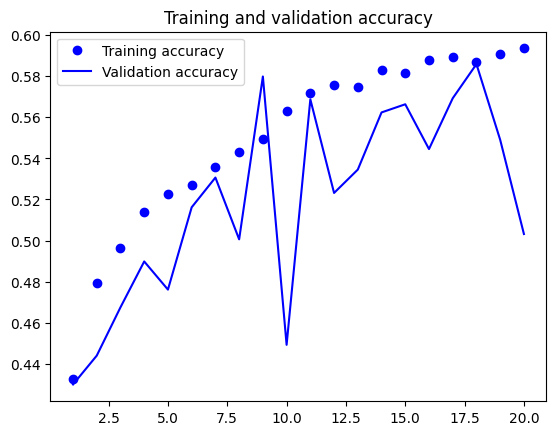

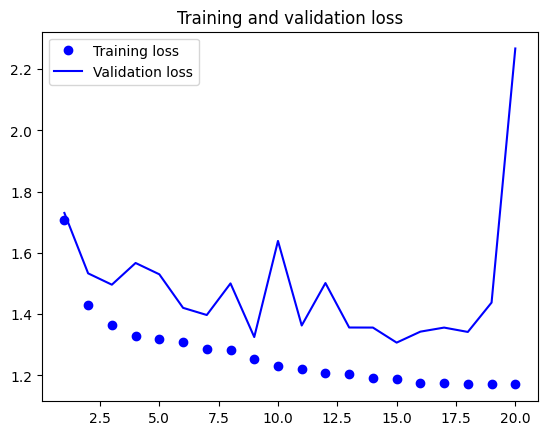

In [76]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [77]:
from IPython.display import FileLink

FileLink('best_model.h5')

/kaggle/working/best_model.h5